In [1]:
import numpy as np
import nibabel as nib
import os.path as op
import pandas as pd

bids_folder = '/Users/mrenke/data/ds-stressrisk'


In [11]:
sub = '08' 
ses = 1

source_dir = op.join(bids_folder, 'derivatives', 'gradients', f'sub-{sub}', f'ses-{ses}')
mask_dir = op.join(bids_folder, 'derivatives', 'ips_masks', f'sub-{sub}')

In [12]:
# load in files

from utils import loadGradAsNpArray

grad1, grad2 = loadGradAsNpArray(sub,ses,bids_folder,'')

r2_L = nib.load(op.join(source_dir,f'sub-{sub}_ses-{ses}_task-risk_space-fsnative_hemi-L_r2.surf.gii'))
r2_R = nib.load(op.join(source_dir,f'sub-{sub}_ses-{ses}_task-risk_space-fsnative_hemi-R_r2.surf.gii'))
r2 = np.concatenate([r2_L.agg_data(), r2_R.agg_data()])

# mask if wanted
#ips_L= nib.load(op.join(mask_dir, f'sub-{sub}_desc-NPC_L_space-fsnative_hemi-lh.ips.gii'))
ips_R= nib.load(op.join(mask_dir, f'sub-{sub}_desc-NPC_R_space-fsnative_hemi-rh.ips.gii'))
r_hemi_mask = ips_R.agg_data()

ips_L_file = op.join(mask_dir, f'sub-{sub}_desc-NPC_L_space-fsnative_hemi-lh.ips.gii')
if op.isfile(ips_L_file):
    ips_L= nib.load(ips_L_file)
    l_hemi_mask = ips_L.agg_data()
else:
    l_hemi_mask = [False] * (len(grad1) - len(r_hemi_mask))

ips_mask = np.concatenate([l_hemi_mask, r_hemi_mask])

<function matplotlib.pyplot.show(close=None, block=None)>

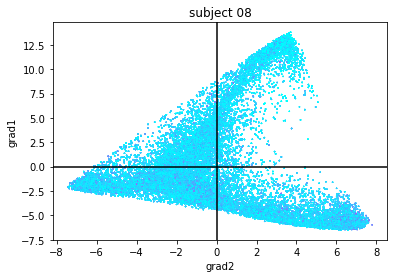

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl


plt.scatter(grad2, grad1, s=0.1, c = r2, cmap = mpl.colormaps['cool'])
plt.axvline(x=0, color = 'black')
plt.axhline(y=0, color = 'black')
plt.xlabel('grad2')
plt.ylabel('grad1')
plt.title(f'subject {sub}')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

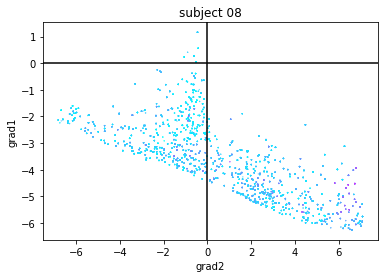

In [14]:
# only right hemisphere
r2_r = r2_R.agg_data()
grad1_r = grad1[(len(grad1)-len(r2_r)):len(grad1)] # (grad1 = np.concatenate([im1L.agg_data(), im1R.agg_data()], axis=0))
grad2_r = grad2[(len(grad1)-len(r2_r)):len(grad1)] # grad2_r = grad2[(len(grad1)-len(r_hemi_mask)):len(grad1)]

r2_r[r_hemi_mask == 0] = np.NaN # needs to be restarted with different subs to work

plt.scatter(grad2_r, grad1_r, s=0.1, c = r2_r, cmap = mpl.colormaps['cool'])
plt.axvline(x=0, color = 'black')
plt.axhline(y=0, color = 'black')
plt.xlabel('grad2')
plt.ylabel('grad1')
plt.title(f'subject {sub}')
plt.show

In [21]:
sub = '02'
mask_dir = op.join(bids_folder, 'derivatives', 'ips_masks', f'sub-{sub}')
ips_R= nib.load(op.join(mask_dir, f'sub-{sub}_desc-NPC_R_space-fsnative_hemi-rh.ips.gii'))
r_hemi_mask = ips_R.agg_data()

source_dir = op.join(bids_folder, 'derivatives', 'gradients', f'sub-{sub}', f'ses-{ses}')
r2_R = nib.load(op.join(source_dir,f'sub-{sub}_ses-{ses}_task-risk_space-fsnative_hemi-R_r2.surf.gii'))
r2_r = r2_R.agg_data()
grad1, grad2 = loadGradAsNpArray(sub,ses,bids_folder,'')
grad1_r = grad1[(len(grad1)-len(r2_r)):len(grad1)] # (grad1 = np.concatenate([im1L.agg_data(), im1R.agg_data()], axis=0))




In [25]:
grad_n = 1
parcel = '_noParcel'
specification = ''
hemi = 'R'
file = op.join(bids_folder, 'derivatives', 'gradients', f'sub-{sub}', f'ses-{ses}',
        f'sub-{sub}_ses-{ses}_task-risk_space-fsnative_hemi-{hemi}_grad{grad_n}{parcel}{specification}.surf.gii')
im1R = nib.load(file)
grad1_r_ = im1R.agg_data()

In [26]:


print(r2_r.shape)
print(r_hemi_mask.shape)
print(grad1_r.shape)
print(grad1_r_.shape)

(147850,)
(147355,)
(147850,)
(147850,)


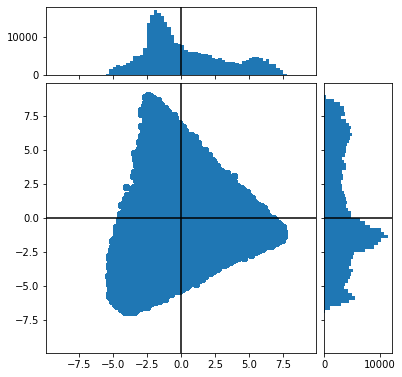

In [19]:
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    ax.scatter(x, y)
    ax.axvline(x=0, color = 'black')
    ax.axhline(y=0, color = 'black')


    # now determine nice limits by hand:
    binwidth = 0.25
    xymax = max(max(np.abs(x)), max(np.abs(y)))
    lim = (int(xymax/binwidth) + 1) * binwidth

    bins = np.arange(-lim, lim + binwidth, binwidth)
    ax_histx.hist(x, bins=bins)
    ax_histy.hist(y, bins=bins, orientation='horizontal')
    ax_histx.axvline(x=0, color = 'black')
    ax_histy.axhline(y=0, color = 'black')

x = grad2
y = grad1

fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

scatter_hist(x, y, ax, ax_histx, ax_histy)